In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
from torchvision import datasets, transforms
import torch

# Define transform for RGB images
transform = transforms.Compose([
    transforms.Resize((64, 64)),                      # Resize to 64x64
    transforms.ToTensor(),                            # Convert to tensor (0-1)
    transforms.Normalize((0.5, 0.5, 0.5),              # Normalize for RGB
                         (0.5, 0.5, 0.5))              
])

# Dataset path
dataset_path = '/kaggle/input/mango-leaf/Train'

# Load dataset
mango_data = datasets.ImageFolder(root=dataset_path, transform=transform)

# DataLoader
data_loader = torch.utils.data.DataLoader(dataset=mango_data,
                                          batch_size=64,
                                          shuffle=True)


In [3]:
dataiter = iter(data_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))


tensor(-1.) tensor(1.)


In [4]:
import torch
import torch.nn as nn

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(3, 16, 4, stride=2, padding=1),   # -> N, 16, 32, 32
            nn.ReLU(),
            nn.Conv2d(16, 32, 4, stride=2, padding=1),  # -> N, 32, 16, 16
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # -> N, 64, 8, 8
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # -> N, 128, 4, 4
            nn.ReLU(),
            nn.Flatten()  # -> N, 128*4*4 = 2048
        )

        self.fc_mu = nn.Linear(2048, 256)
        self.fc_logvar = nn.Linear(2048, 256)
        self.fc_decode = nn.Linear(256, 2048)

        # Decoder
        self.decoder_cnn = nn.Sequential(
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # -> N, 64, 8, 8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # -> N, 32, 16, 16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),   # -> N, 16, 32, 32
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1),    # -> N, 3, 64, 64
            nn.Tanh()
        )

    def encode(self, x):
        x = self.encoder_cnn(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.fc_decode(z)
        x = self.decoder_cnn(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


In [5]:
model = VAE()  # Use your VAE model

optimizer = torch.optim.Adam(model.parameters(),
                             lr=1e-3, 
                             weight_decay=1e-5)

# Loss function for reconstruction
reconstruction_criterion = nn.MSELoss(reduction='sum')

def loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss
    recon_loss = reconstruction_criterion(recon_x, x)

    # KL Divergence loss
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss


In [6]:
import torch

num_epochs = 250
outputs = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Use the custom loss function (reconstruction + KL divergence)
reconstruction_criterion = nn.MSELoss(reduction='sum')

def loss_function(recon_x, x, mu, logvar):
    recon_loss = reconstruction_criterion(recon_x, x)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

for epoch in range(num_epochs):
    total_loss = 0
    for (img, _) in data_loader:
        img = img.to(device)

        # Forward pass
        recon, mu, logvar = model(img)
        loss = loss_function(recon, img, mu, logvar)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f'Epoch:{epoch+1}, Loss:{total_loss/len(data_loader.dataset):.4f}')
    outputs.append((epoch, img, recon))


Epoch:1, Loss:2055.8459
Epoch:2, Loss:1277.5276
Epoch:3, Loss:1101.1545
Epoch:4, Loss:865.9884
Epoch:5, Loss:624.2777
Epoch:6, Loss:560.3098
Epoch:7, Loss:509.7836
Epoch:8, Loss:473.8862
Epoch:9, Loss:448.1710
Epoch:10, Loss:427.2333
Epoch:11, Loss:414.3855
Epoch:12, Loss:393.6641
Epoch:13, Loss:383.7545
Epoch:14, Loss:372.3820
Epoch:15, Loss:365.2574
Epoch:16, Loss:357.0070
Epoch:17, Loss:350.8512
Epoch:18, Loss:342.0654
Epoch:19, Loss:333.7190
Epoch:20, Loss:330.9776
Epoch:21, Loss:325.7948
Epoch:22, Loss:322.4761
Epoch:23, Loss:315.6018
Epoch:24, Loss:312.9825
Epoch:25, Loss:308.2236
Epoch:26, Loss:305.7665
Epoch:27, Loss:300.7659
Epoch:28, Loss:297.4560
Epoch:29, Loss:295.4413
Epoch:30, Loss:291.3918
Epoch:31, Loss:286.5864
Epoch:32, Loss:285.8904
Epoch:33, Loss:281.5322
Epoch:34, Loss:278.9082
Epoch:35, Loss:277.2962
Epoch:36, Loss:275.9121
Epoch:37, Loss:273.2940
Epoch:38, Loss:271.9140
Epoch:39, Loss:268.8598
Epoch:40, Loss:268.8435
Epoch:41, Loss:266.7693
Epoch:42, Loss:264.822

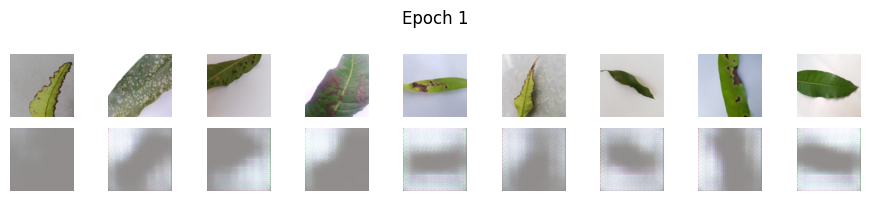

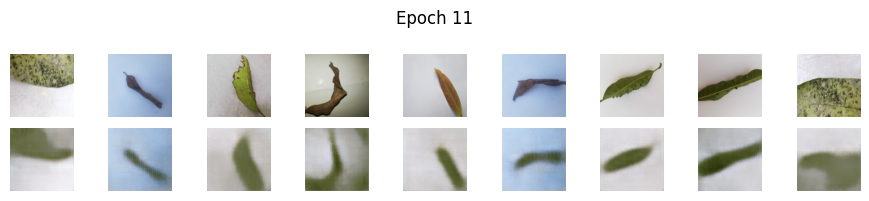

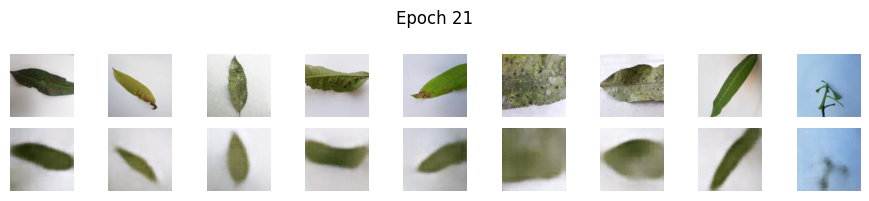

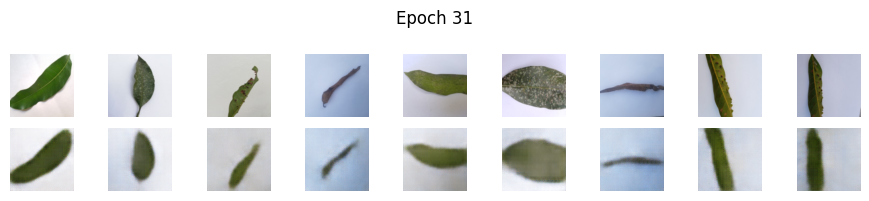

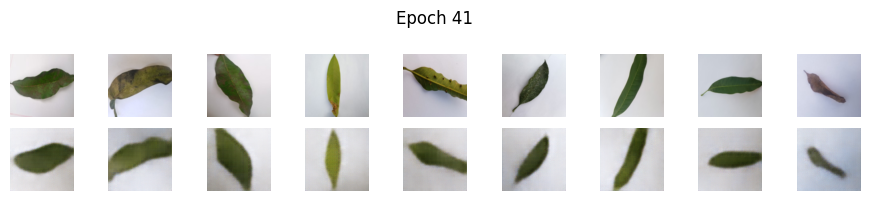

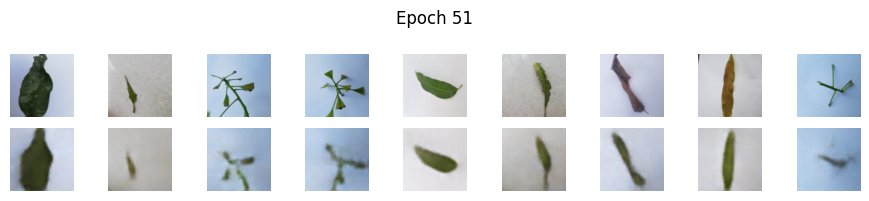

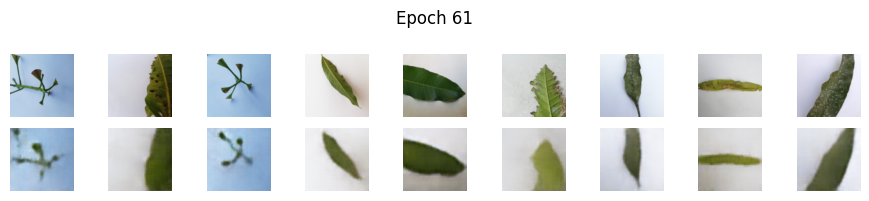

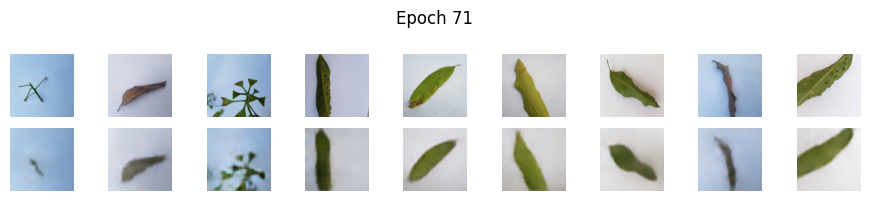

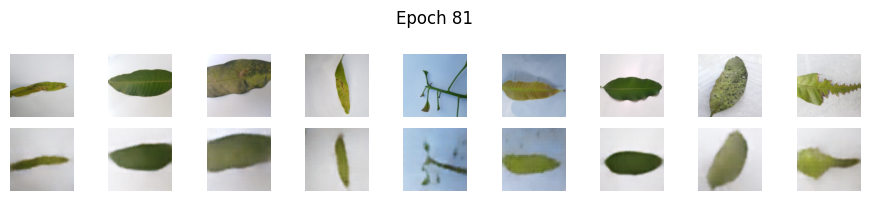

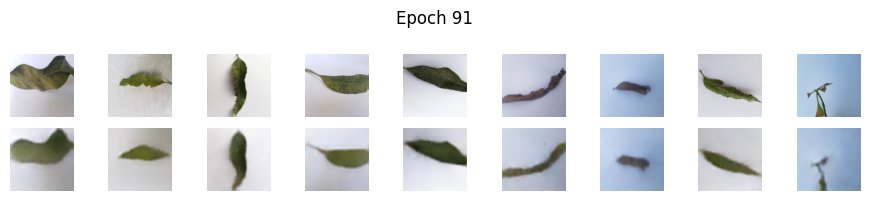

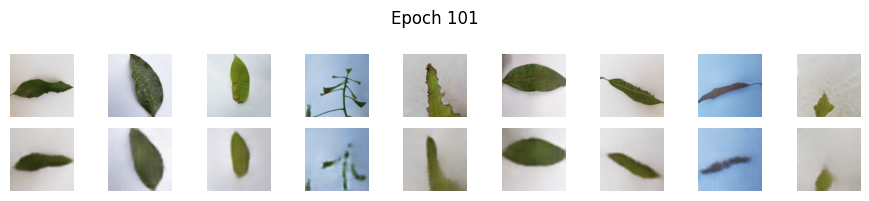

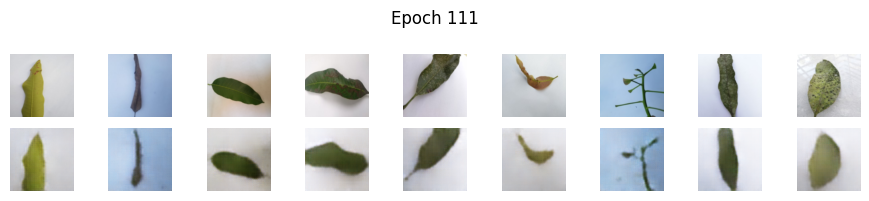

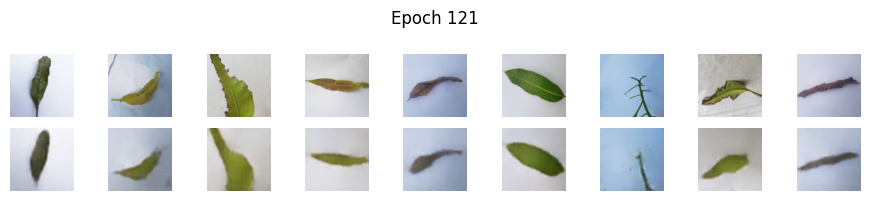

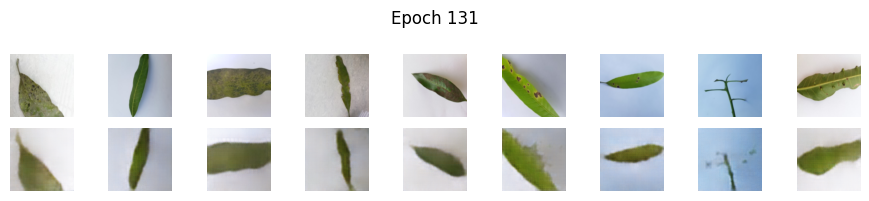

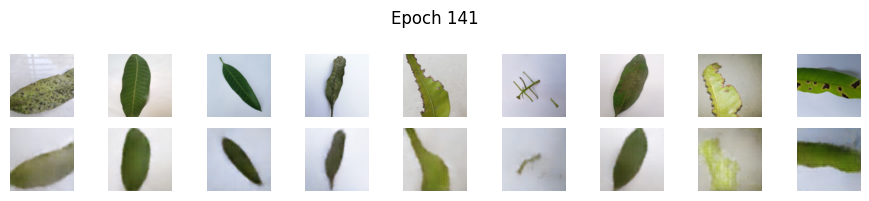

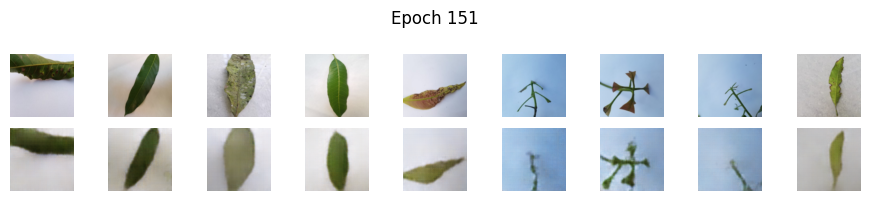

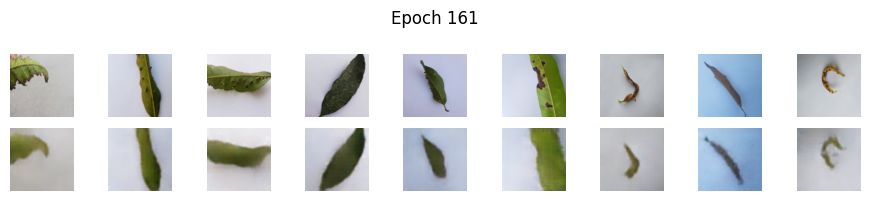

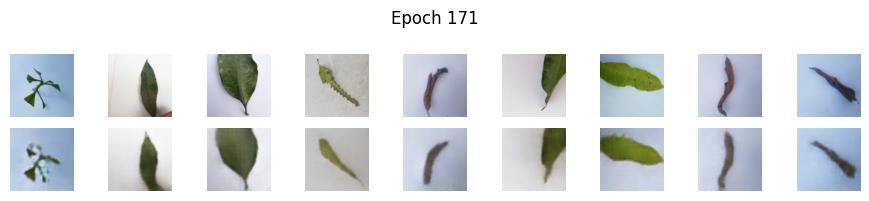

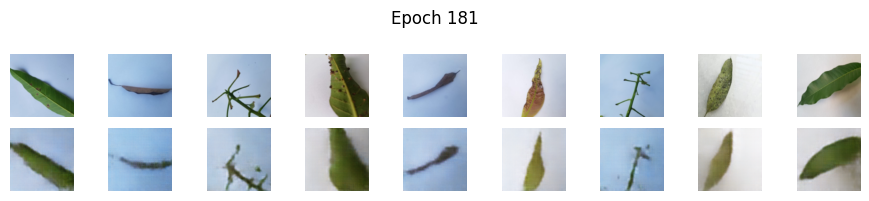

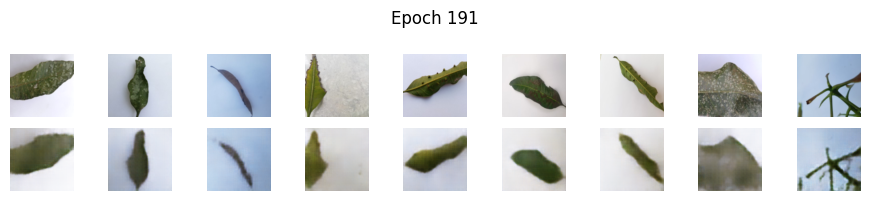

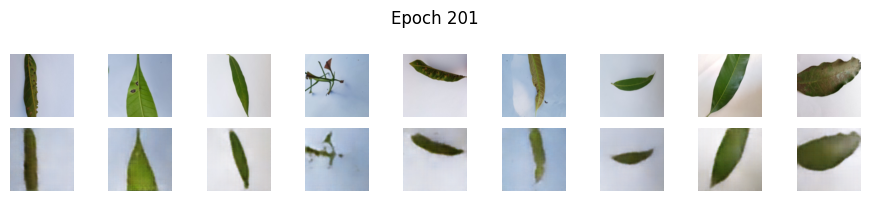

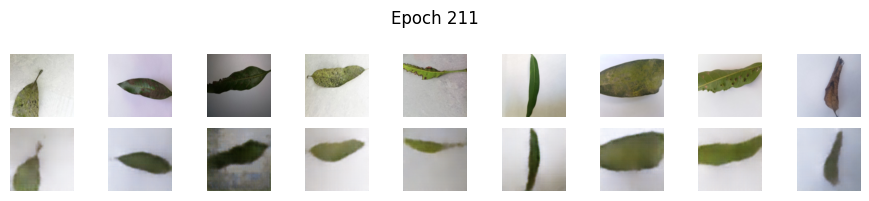

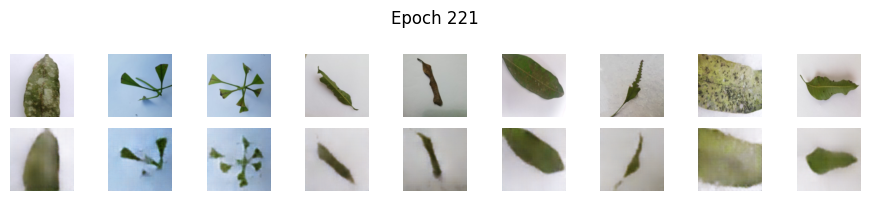

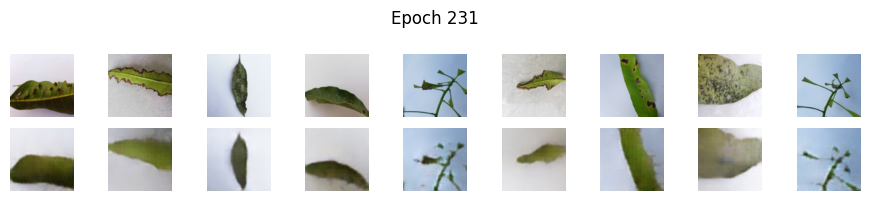

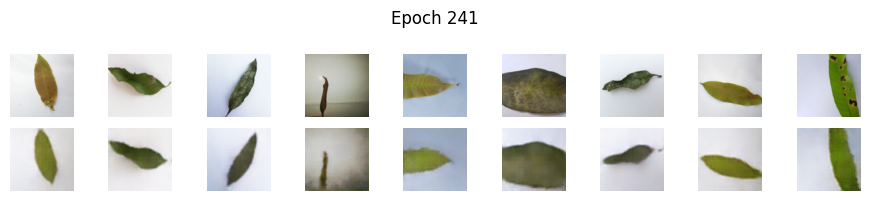

In [7]:
import matplotlib.pyplot as plt
import numpy as np

for k in range(0, num_epochs, 10):
    plt.figure(figsize=(9, 2))
    imgs = outputs[k][1].detach().cpu().numpy()
    recon = outputs[k][2].detach().cpu().numpy()

    # Denormalize from [-1, 1] to [0, 1]
    imgs = (imgs + 1) / 2
    recon = (recon + 1) / 2

    for i, item in enumerate(imgs):
        if i >= 9: break
        plt.subplot(2, 9, i+1)
        plt.imshow(np.clip(item.transpose(1, 2, 0), 0, 1))
        plt.axis('off')

    for i, item in enumerate(recon):
        if i >= 9: break
        plt.subplot(2, 9, 9+i+1)
        plt.imshow(np.clip(item.transpose(1, 2, 0), 0, 1))
        plt.axis('off')

    plt.suptitle(f"Epoch {outputs[k][0] + 1}")
    plt.tight_layout()
    plt.show()


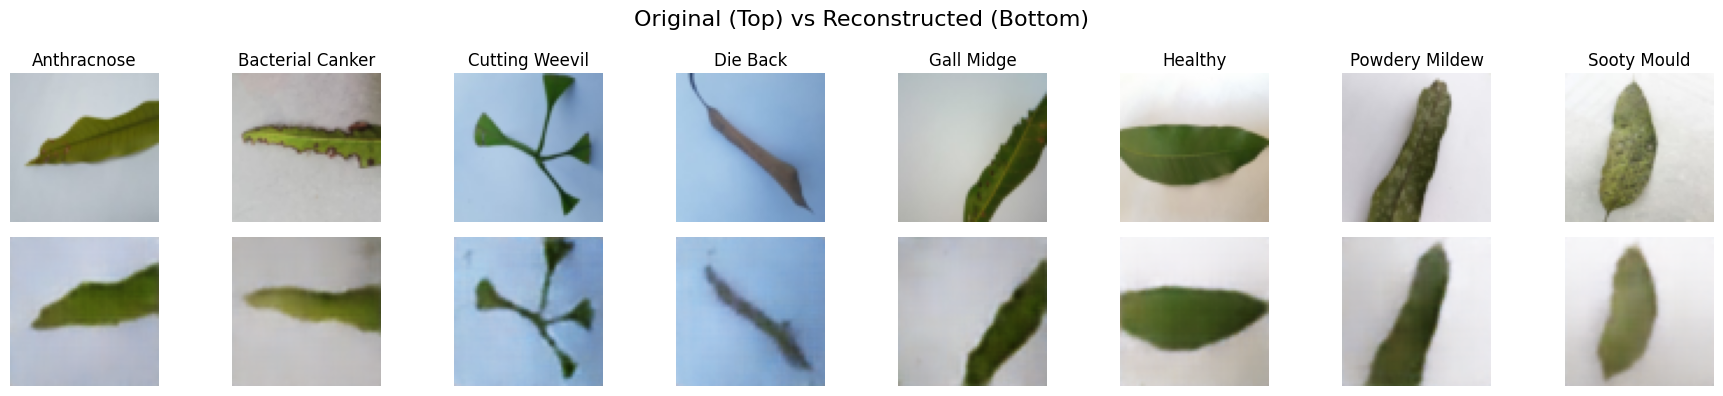

In [8]:
import os
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Set model to eval mode
model.eval()

# Define same transform used during training
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# Path to test set
test_root = '/kaggle/input/mango-leaf/Test'

# List of classes (same order as folders)
classes = sorted(os.listdir(test_root))

# Store inputs and outputs
test_imgs = []
recon_imgs = []

for cls in classes:
    class_path = os.path.join(test_root, cls)
    if not os.path.isdir(class_path):
        continue

    # Take the first image in the class folder
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    
    # Load and preprocess
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)  # add batch dim

    # Reconstruct
    with torch.no_grad():
        recon, _, _ = model(img_tensor)

    test_imgs.append(img_tensor.squeeze(0).cpu())
    recon_imgs.append(recon.squeeze(0).cpu())

# Visualize
plt.figure(figsize=(18, 4))
for i in range(len(classes)):
    # Original
    plt.subplot(2, len(classes), i + 1)
    plt.imshow(test_imgs[i].permute(1, 2, 0) * 0.5 + 0.5)  # unnormalize
    plt.title(f'{classes[i]}')
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, len(classes), len(classes) + i + 1)
    plt.imshow(recon_imgs[i].permute(1, 2, 0) * 0.5 + 0.5)
    plt.axis('off')

plt.suptitle("Original (Top) vs Reconstructed (Bottom)", fontsize=16)
plt.tight_layout()
plt.show()


In [9]:
import os
import zipfile
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Set model to eval mode
model.eval()

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

test_root = '/kaggle/input/mango-leaf/Test'
classes = sorted(os.listdir(test_root))

# Directory to save plots
os.makedirs("vae_reconstructions", exist_ok=True)

# Save up to 100 images
count = 0
max_plots = 100

for cls in classes:
    class_path = os.path.join(test_root, cls)
    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        if count >= max_plots:
            break

        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path).convert("RGB")
        except:
            continue

        img_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            recon, _, _ = model(img_tensor)

        img_tensor = img_tensor.squeeze(0).cpu()
        recon = recon.squeeze(0).cpu()

        # Plot
        plt.figure(figsize=(6, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(img_tensor.permute(1, 2, 0) * 0.5 + 0.5)
        plt.title("Original")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(recon.permute(1, 2, 0) * 0.5 + 0.5)
        plt.title("Reconstructed")
        plt.axis('off')

        plt.suptitle(f"{cls}", fontsize=12)
        plt.tight_layout()

        # Save plot
        plot_path = f"vae_reconstructions/recon_{count:03}_{cls}.png"
        plt.savefig(plot_path)
        plt.close()

        count += 1

# Create zip for download
zipfile_name = "vae_reconstructions.zip"
with zipfile.ZipFile(zipfile_name, "w") as zipf:
    for root, dirs, files in os.walk("vae_reconstructions"):
        for file in files:
            zipf.write(os.path.join(root, file), arcname=file)

print(f"{count} reconstruction plots saved and zipped!")


100 reconstruction plots saved and zipped!


In [10]:
!pip install scikit-image
from skimage.metrics import structural_similarity as ssim
import numpy as n


In [11]:
'''
def calculate_ssim(original, reconstructed):
    # Convert tensors to numpy and unnormalize to [0,1]
    original = original.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5
    reconstructed = reconstructed.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5

    # Compute SSIM for each channel and average
    ssim_score = 0
    for i in range(3):  # RGB
        ssim_score += ssim(original[..., i], reconstructed[..., i], data_range=1.0)

    return ssim_score / 3
'''

'\ndef calculate_ssim(original, reconstructed):\n    # Convert tensors to numpy and unnormalize to [0,1]\n    original = original.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5\n    reconstructed = reconstructed.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5\n\n    # Compute SSIM for each channel and average\n    ssim_score = 0\n    for i in range(3):  # RGB\n        ssim_score += ssim(original[..., i], reconstructed[..., i], data_range=1.0)\n\n    return ssim_score / 3\n'

In [12]:
''''!pip install pytorch-fid
from pytorch_fid import fid_score
'''

"'!pip install pytorch-fid\nfrom pytorch_fid import fid_score\n"

In [13]:
'''import torchvision.utils as vutils
import os

real_dir = "./real_images"
fake_dir = "./recon_images"
os.makedirs(real_dir, exist_ok=True)
os.makedirs(fake_dir, exist_ok=True)

# Save images
for i, (real, recon) in enumerate(zip(test_imgs, recon_imgs)):
    vutils.save_image(real, os.path.join(real_dir, f"{i}_real.png"), normalize=True)
    vutils.save_image(recon, os.path.join(fake_dir, f"{i}_recon.png"), normalize=True)
'''

'import torchvision.utils as vutils\nimport os\n\nreal_dir = "./real_images"\nfake_dir = "./recon_images"\nos.makedirs(real_dir, exist_ok=True)\nos.makedirs(fake_dir, exist_ok=True)\n\n# Save images\nfor i, (real, recon) in enumerate(zip(test_imgs, recon_imgs)):\n    vutils.save_image(real, os.path.join(real_dir, f"{i}_real.png"), normalize=True)\n    vutils.save_image(recon, os.path.join(fake_dir, f"{i}_recon.png"), normalize=True)\n'

In [14]:
'''fid_value = fid_score.calculate_fid_given_paths([real_dir, fake_dir], 
                                                batch_size=8, 
                                                device=device, 
                                                dims=2048)
print("FID Score:", fid_value)
'''

'fid_value = fid_score.calculate_fid_given_paths([real_dir, fake_dir], \n                                                batch_size=8, \n                                                device=device, \n                                                dims=2048)\nprint("FID Score:", fid_value)\n'

In [15]:
'''ssim_scores = [calculate_ssim(orig, recon) for orig, recon in zip(test_imgs, recon_imgs)]
avg_ssim = sum(ssim_scores) / len(ssim_scores)
print(f"Average SSIM: {avg_ssim:.4f}")
'''

'ssim_scores = [calculate_ssim(orig, recon) for orig, recon in zip(test_imgs, recon_imgs)]\navg_ssim = sum(ssim_scores) / len(ssim_scores)\nprint(f"Average SSIM: {avg_ssim:.4f}")\n'